1. Nguyễn Thành Lộc
2. 2351060016
3. BTVN_RNN

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import time
import math
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import string
import unicodedata
import re
import io

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Create output directory
output_dir = "07_recurrent_neural_networks_outputs"
os.makedirs(output_dir, exist_ok=True)
os.makedirs(os.path.join(output_dir, "generated_text"), exist_ok=True)
os.makedirs(os.path.join(output_dir, "plots"), exist_ok=True)

Using device: cpu


## Section 1

In [12]:
# Section 1: RNN, LSTM, and GRU Implementations
# -----------------------------------------------------------------------------

class SimpleRNN(nn.Module):
    """A simple Recurrent Neural Network."""
    def __init__(self, input_size, hidden_size, output_size):
        super(SimpleRNN, self).__init__()
        self.hidden_size = hidden_size
        
        # RNN layer
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        
        # Output layer
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x, hidden=None):
        # Forward pass through RNN
        # x shape: (batch_size, sequence_length, input_size)
        # hidden shape: (1, batch_size, hidden_size)
        if hidden is None:
            # Initialize hidden state with zeros if not provided
            batch_size = x.size(0)
            hidden = torch.zeros(1, batch_size, self.hidden_size, device=device)
        
        # RNN output
        # out shape: (batch_size, sequence_length, hidden_size)
        # h_n shape: (1, batch_size, hidden_size)
        out, h_n = self.rnn(x, hidden)
        
        # Decode the hidden state of the last time step
        # out[:, -1, :] shape: (batch_size, hidden_size)
        # output shape: (batch_size, output_size)
        output = self.fc(out[:, -1, :])
        
        return output, h_n

class SimpleLSTM(nn.Module):
    """A simple Long Short-Term Memory Network."""
    def __init__(self, input_size, hidden_size, output_size, num_layers=1, dropout=0):
        super(SimpleLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # LSTM layer
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                           batch_first=True, dropout=dropout if num_layers > 1 else 0)
        
        # Output layer
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x, hidden=None):
        # Forward pass through LSTM
        # x shape: (batch_size, sequence_length, input_size)
        # hidden shape: (num_layers, batch_size, hidden_size) for h_0 and c_0
        if hidden is None:
            # Initialize hidden state with zeros if not provided
            batch_size = x.size(0)
            h_0 = torch.zeros(self.num_layers, batch_size, self.hidden_size, device=device)
            c_0 = torch.zeros(self.num_layers, batch_size, self.hidden_size, device=device)
            hidden = (h_0, c_0)
        
        # LSTM output
        # out shape: (batch_size, sequence_length, hidden_size)
        # h_n, c_n shape: (num_layers, batch_size, hidden_size)
        out, (h_n, c_n) = self.lstm(x, hidden)
        
        # Decode the hidden state of the last time step
        # out[:, -1, :] shape: (batch_size, hidden_size)
        # output shape: (batch_size, output_size)
        output = self.fc(out[:, -1, :])
        
        return output, (h_n, c_n)

class SimpleGRU(nn.Module):
    """A simple Gated Recurrent Unit Network."""
    def __init__(self, input_size, hidden_size, output_size, num_layers=1, dropout=0):
        super(SimpleGRU, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # GRU layer
        self.gru = nn.GRU(input_size, hidden_size, num_layers, 
                         batch_first=True, dropout=dropout if num_layers > 1 else 0)
        
        # Output layer
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x, hidden=None):
        # Forward pass through GRU
        # x shape: (batch_size, sequence_length, input_size)
        # hidden shape: (num_layers, batch_size, hidden_size)
        if hidden is None:
            # Initialize hidden state with zeros if not provided
            batch_size = x.size(0)
            hidden = torch.zeros(self.num_layers, batch_size, self.hidden_size, device=device)
        
        # GRU output
        # out shape: (batch_size, sequence_length, hidden_size)
        # h_n shape: (num_layers, batch_size, hidden_size)
        out, h_n = self.gru(x, hidden)
        
        # Decode the hidden state of the last time step
        # out[:, -1, :] shape: (batch_size, hidden_size)
        # output shape: (batch_size, output_size)
        output = self.fc(out[:, -1, :])
        
        return output, h_n

class BidirectionalRNN(nn.Module):
    """A Bidirectional RNN (can be RNN, LSTM, or GRU)."""
    def __init__(self, input_size, hidden_size, output_size, rnn_type='lstm', num_layers=1, dropout=0):
        super(BidirectionalRNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn_type = rnn_type.lower()
        
        # Select RNN type
        if self.rnn_type == 'rnn':
            self.rnn = nn.RNN(input_size, hidden_size, num_layers, 
                             batch_first=True, bidirectional=True, 
                             dropout=dropout if num_layers > 1 else 0)
        elif self.rnn_type == 'lstm':
            self.rnn = nn.LSTM(input_size, hidden_size, num_layers, 
                              batch_first=True, bidirectional=True, 
                              dropout=dropout if num_layers > 1 else 0)
        elif self.rnn_type == 'gru':
            self.rnn = nn.GRU(input_size, hidden_size, num_layers, 
                             batch_first=True, bidirectional=True, 
                             dropout=dropout if num_layers > 1 else 0)
        else:
            raise ValueError("Unsupported RNN type. Use 'rnn', 'lstm', or 'gru'.")
        
        # Output layer (note: bidirectional doubles the size)
        self.fc = nn.Linear(hidden_size * 2, output_size)
    
    def forward(self, x, hidden=None):
        # Forward pass through bidirectional RNN
        # x shape: (batch_size, sequence_length, input_size)
        batch_size = x.size(0)
        
        # Initialize hidden state if not provided
        if hidden is None:
            if self.rnn_type == 'lstm':
                h_0 = torch.zeros(self.num_layers * 2, batch_size, self.hidden_size, device=device)
                c_0 = torch.zeros(self.num_layers * 2, batch_size, self.hidden_size, device=device)
                hidden = (h_0, c_0)
            else:  # RNN or GRU
                hidden = torch.zeros(self.num_layers * 2, batch_size, self.hidden_size, device=device)
        
        # RNN output
        if self.rnn_type == 'lstm':
            out, (h_n, c_n) = self.rnn(x, hidden)
            hidden_states = (h_n, c_n)
        else:  # RNN or GRU
            out, h_n = self.rnn(x, hidden)
            hidden_states = h_n
        
        # Combine the forward and backward hidden states
        # out shape: (batch_size, sequence_length, hidden_size*2)
        output = self.fc(out[:, -1, :])
        
        return output, hidden_states

def demonstrate_rnn_architectures():
    """Demonstrate and explain various RNN architectures."""
    print("RNN Architecture Implementations:")
    print("-" * 50)
    
    # Create sample data to show dimensions
    batch_size = 10
    seq_length = 5
    input_size = 3
    hidden_size = 8
    output_size = 2
    
    # Sample input tensor
    sample_input = torch.randn(batch_size, seq_length, input_size).to(device)
    
    # 1. Simple RNN
    print("\n1. Simple RNN")
    simple_rnn = SimpleRNN(input_size, hidden_size, output_size).to(device)
    rnn_output, rnn_hidden = simple_rnn(sample_input)
    print(f"  Input shape: {sample_input.shape}")
    print(f"  Output shape: {rnn_output.shape}")
    print(f"  Hidden state shape: {rnn_hidden.shape}")
    
    # 2. LSTM
    print("\n2. Long Short-Term Memory (LSTM)")
    lstm = SimpleLSTM(input_size, hidden_size, output_size).to(device)
    lstm_output, (h_n, c_n) = lstm(sample_input)
    print(f"  Input shape: {sample_input.shape}")
    print(f"  Output shape: {lstm_output.shape}")
    print(f"  Hidden state (h_n) shape: {h_n.shape}")
    print(f"  Cell state (c_n) shape: {c_n.shape}")
    
    # 3. GRU
    print("\n3. Gated Recurrent Unit (GRU)")
    gru = SimpleGRU(input_size, hidden_size, output_size).to(device)
    gru_output, gru_hidden = gru(sample_input)
    print(f"  Input shape: {sample_input.shape}")
    print(f"  Output shape: {gru_output.shape}")
    print(f"  Hidden state shape: {gru_hidden.shape}")
    
    # 4. Bidirectional LSTM
    print("\n4. Bidirectional LSTM")
    bi_lstm = BidirectionalRNN(input_size, hidden_size, output_size, rnn_type='lstm').to(device)
    bi_output, (bi_h_n, bi_c_n) = bi_lstm(sample_input)
    print(f"  Input shape: {sample_input.shape}")
    print(f"  Output shape: {bi_output.shape}")
    print(f"  Hidden state (h_n) shape: {bi_h_n.shape}")
    print(f"  Cell state (c_n) shape: {bi_c_n.shape}")
    
    print("\nKey Differences Between RNN Types:")
    print("  - RNN: Simple structure, prone to vanishing gradients")
    print("  - LSTM: Complex structure with gates, good at capturing long-term dependencies")
    print("  - GRU: Simplified version of LSTM, often comparable performance with fewer parameters")
    print("  - Bidirectional: Processes sequences in both directions for better context")

# Simple example to understand the mechanics of RNNs
def generate_sine_wave():
    """Generate a simple sine wave for sequence prediction tasks."""
    seq_length = 100
    time_steps = np.linspace(0, 10, seq_length)
    data = np.sin(time_steps)
    return data

def prepare_sine_data(seq_length=20, pred_length=5):
    """Prepare sine wave data for sequence prediction."""
    sine_wave = generate_sine_wave()
    
    # Create sequences
    x_data, y_data = [], []
    for i in range(len(sine_wave) - seq_length - pred_length):
        x = sine_wave[i:i+seq_length]
        y = sine_wave[i+seq_length:i+seq_length+pred_length]
        x_data.append(x)
        y_data.append(y)
    
    # Convert to tensors and reshape
    x_tensor = torch.FloatTensor(x_data).unsqueeze(-1)  # [batch, seq_len, features]
    y_tensor = torch.FloatTensor(y_data)
    
    # Create train/test split
    train_size = int(0.8 * len(x_tensor))
    x_train, y_train = x_tensor[:train_size], y_tensor[:train_size]
    x_test, y_test = x_tensor[train_size:], y_tensor[train_size:]
    
    return (x_train, y_train), (x_test, y_test)

def train_sine_prediction(model, train_data, test_data, epochs=100):
    """Train an RNN model to predict sine wave values."""
    x_train, y_train = train_data
    x_test, y_test = test_data
    
    # Create DataLoaders
    train_dataset = TensorDataset(x_train, y_train)
    test_dataset = TensorDataset(x_test, y_test)
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)
    
    # Loss function and optimizer
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    
    # Lists to store metrics
    train_losses = []
    test_losses = []
    
    # Training loop
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            
            # Forward pass
            optimizer.zero_grad()
            output, _ = model(x_batch)
            loss = criterion(output, y_batch)
            
            # Backward pass and optimize
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        # Evaluation
        model.eval()
        test_loss = 0
        with torch.no_grad():
            for x_batch, y_batch in test_loader:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                output, _ = model(x_batch)
                loss = criterion(output, y_batch)
                test_loss += loss.item()
        
        # Calculate average losses
        train_loss /= len(train_loader)
        test_loss /= len(test_loader)
        
        # Store losses
        train_losses.append(train_loss)
        test_losses.append(test_loss)
        
        # Print progress every 10 epochs
        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}')
    
    return train_losses, test_losses

def compare_rnn_architectures_on_sine():
    """Compare different RNN architectures on sine wave prediction."""
    print("\nComparing RNN Architectures on Sine Wave Prediction")
    print("-" * 60)
    
    # Prepare data
    train_data, test_data = prepare_sine_data()
    input_size = 1  # Single feature (sine value)
    hidden_size = 32
    output_size = 5  # Predict next 5 values
    
    # Initialize different models
    models = {
        'SimpleRNN': SimpleRNN(input_size, hidden_size, output_size).to(device),
        'SimpleLSTM': SimpleLSTM(input_size, hidden_size, output_size).to(device),
        'SimpleGRU': SimpleGRU(input_size, hidden_size, output_size).to(device),
        'BidirectionalLSTM': BidirectionalRNN(input_size, hidden_size, output_size, 'lstm').to(device)
    }
    
    # Train and evaluate each model
    results = {}
    for name, model in models.items():
        print(f"\nTraining {name}...")
        train_losses, test_losses = train_sine_prediction(model, train_data, test_data, epochs=50)
        results[name] = {
            'model': model,
            'train_losses': train_losses,
            'test_losses': test_losses,
            'final_test_loss': test_losses[-1]
        }
    
    # Plot training curves
    plt.figure(figsize=(12, 6))
    for name, result in results.items():
        plt.plot(result['test_losses'], label=f"{name} (Final Loss: {result['final_test_loss']:.4f})")
    
    plt.title('Test Loss Comparison Between RNN Architectures')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "plots", "rnn_architecture_comparison.png"))
    
    # Plot predictions for best model
    best_model_name = min(results, key=lambda k: results[k]['final_test_loss'])
    best_model = results[best_model_name]['model']
    
    # Generate predictions
    x_test, y_test = test_data
    x_sample = x_test[:3].to(device)
    true_values = y_test[:3].cpu().numpy()
    
    with torch.no_grad():
        predicted, _ = best_model(x_sample)
        predicted = predicted.cpu().numpy()
    
    # Visualize the predictions
    plt.figure(figsize=(12, 6))
    for i in range(3):  # Plot first 3 test sequences
        plt.subplot(3, 1, i+1)
        
        # Plot input sequence
        plt.plot(range(20), x_test[i].squeeze().cpu().numpy(), 'b-', label='Input Sequence')
        
        # Plot true future values
        plt.plot(range(20, 25), true_values[i], 'g-', label='True Future')
        
        # Plot predicted values
        plt.plot(range(20, 25), predicted[i], 'r--', label='Predicted Future')
        
        plt.title(f'Sequence {i+1}: Prediction using {best_model_name}')
        plt.legend()
        plt.grid(True)
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "plots", "rnn_predictions.png"))
    
    print(f"\nBest performing model: {best_model_name} with final test loss: {results[best_model_name]['final_test_loss']:.4f}")
    return results 


## Section 2

In [28]:
# Section 2: Sequence Modeling
# -----------------------------------------------------------------------------

class SequenceClassifier(nn.Module):
    """RNN-based sequence classifier."""
    def __init__(self, input_size, hidden_size, output_size, rnn_type='lstm', 
                 num_layers=1, bidirectional=False, dropout=0.0):
        super(SequenceClassifier, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn_type = rnn_type.lower()
        self.bidirectional = bidirectional
        
        # Choose RNN type
        if self.rnn_type == 'lstm':
            self.rnn = nn.LSTM(input_size, hidden_size, num_layers, 
                              batch_first=True, bidirectional=bidirectional, 
                              dropout=dropout if num_layers > 1 else 0)
        elif self.rnn_type == 'gru':
            self.rnn = nn.GRU(input_size, hidden_size, num_layers, 
                             batch_first=True, bidirectional=bidirectional, 
                             dropout=dropout if num_layers > 1 else 0)
        else:
            self.rnn = nn.RNN(input_size, hidden_size, num_layers, 
                             batch_first=True, bidirectional=bidirectional, 
                             dropout=dropout if num_layers > 1 else 0)
        
        # Output layer
        # If bidirectional, we have 2x hidden_size features
        fc_input_size = hidden_size * 2 if bidirectional else hidden_size
        self.fc = nn.Linear(fc_input_size, output_size)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, lengths=None, hidden=None):
        batch_size = x.size(0)
        
        # Initial hidden state if not provided
        if hidden is None:
            if self.rnn_type == 'lstm':
                h_mult = 2 if self.bidirectional else 1
                h_0 = torch.zeros(self.num_layers * h_mult, batch_size, self.hidden_size, device=device)
                c_0 = torch.zeros(self.num_layers * h_mult, batch_size, self.hidden_size, device=device)
                hidden = (h_0, c_0)
            else:
                h_mult = 2 if self.bidirectional else 1
                hidden = torch.zeros(self.num_layers * h_mult, batch_size, self.hidden_size, device=device)
        
        # Pack padded sequence if lengths are provided
        if lengths is not None:
            x_packed = pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
            
            # Run RNN
            if self.rnn_type == 'lstm':
                packed_output, (h_n, c_n) = self.rnn(x_packed, hidden)
            else:
                packed_output, h_n = self.rnn(x_packed, hidden)
            
            # Unpack output
            output, _ = pad_packed_sequence(packed_output, batch_first=True)
        else:
            # Run RNN without packing
            if self.rnn_type == 'lstm':
                output, (h_n, c_n) = self.rnn(x, hidden)
            else:
                output, h_n = self.rnn(x, hidden)
        
        # Get final hidden state for sequence classification
        if self.bidirectional:
            # Combine forward and backward final hidden states
            if self.rnn_type == 'lstm':
                # Get last layer's hidden state for both directions
                h_forward = h_n[2*self.num_layers-2, :, :]
                h_backward = h_n[2*self.num_layers-1, :, :]
                final_hidden = torch.cat((h_forward, h_backward), dim=1)
            else:
                h_forward = h_n[2*self.num_layers-2, :, :]
                h_backward = h_n[2*self.num_layers-1, :, :]
                final_hidden = torch.cat((h_forward, h_backward), dim=1)
        else:
            if self.rnn_type == 'lstm':
                final_hidden = h_n[-1, :, :]  # Last layer's hidden state
            else:
                final_hidden = h_n[-1, :, :]
        
        # Apply dropout to final hidden state
        final_hidden = self.dropout(final_hidden)
        
        # Apply the fully connected layer for prediction
        output = self.fc(final_hidden)
        
        return output

def prepare_imdb_data(max_features=10000, max_len=200):
    """Prepare IMDB sentiment analysis dataset."""
    print("Preparing IMDB dataset...")
    
    # IMDB dataset from torchtext
    try:
        from torchtext.legacy import data, datasets
        
        # Set up Fields
        TEXT = data.Field(tokenize='spacy', batch_first=True, include_lengths=True, fix_length=max_len)
        LABEL = data.LabelField(dtype=torch.float)
        
        # Load IMDB dataset
        train_data, test_data = datasets.IMDB.splits(TEXT, LABEL)
        
        # Build vocabulary
        TEXT.build_vocab(train_data, max_size=max_features)
        LABEL.build_vocab(train_data)
        
        # Create iterators
        train_iterator, test_iterator = data.BucketIterator.splits(
            (train_data, test_data), 
            batch_size=64,
            sort_within_batch=True,
            device=device
        )
        
        return train_iterator, test_iterator, TEXT.vocab, LABEL.vocab
    
    except ImportError:
        print("torchtext.legacy not available. Using a simplified example dataset...")
        
        # Generate a simple synthetic dataset
        # Positive examples: sequences with more 1s than 0s
        # Negative examples: sequences with more 0s than 1s
        num_samples = 1000
        seq_length = 50
        
        X = []
        y = []
        
        for _ in range(num_samples):
            # Generate random sequence of 0s and 1s
            seq = np.random.randint(0, 2, size=(seq_length, 1)).astype(np.float32)
            label = 1.0 if np.sum(seq) > seq_length / 2 else 0.0
            
            X.append(torch.FloatTensor(seq))
            y.append(label)
        
        # Convert to tensors
        X = torch.stack(X)
        y = torch.FloatTensor(y)
        
        # Split into train and test
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
        # Create TensorDatasets
        train_dataset = TensorDataset(X_train, y_train)
        test_dataset = TensorDataset(X_test, y_test)
        
        # Create DataLoaders
        train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
        test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
        
        # Create dummy vocab objects
        class DummyVocab:
            def __init__(self, size):
                self.size = size
        
        return train_loader, test_loader, DummyVocab(2), DummyVocab(2)

def train_sentiment_classifier(model, train_iter, test_iter, epochs=5):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    train_losses, test_losses, train_accs, test_accs = [], [], [], []
    
    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        
        for batch in train_iter:
            # --- PHẦN SỬA LỖI TẠI ĐÂY ---
            if isinstance(batch, (list, tuple)):
                # Nếu batch là list (Dữ liệu giả lập)
                inputs, labels = batch[0].to(device), batch[1].to(device)
                lengths = None
            else:
                # Nếu batch là đối tượng torchtext (Dữ liệu thật)
                inputs, lengths = batch.text
                labels = batch.label.to(device)
            # ----------------------------

            optimizer.zero_grad()
            outputs = model(inputs, lengths).squeeze()
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            predicted = torch.sigmoid(outputs) >= 0.5
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
        
        # Phần Evaluation (Đánh giá) cũng phải sửa tương tự
        model.eval()
        test_loss, test_correct, test_total = 0, 0, 0
        with torch.no_grad():
            for batch in test_iter:
                # --- PHẦN SỬA LỖI TẠI ĐÂY ---
                if isinstance(batch, (list, tuple)):
                    inputs, labels = batch[0].to(device), batch[1].to(device)
                    lengths = None
                else:
                    inputs, lengths = batch.text
                    labels = batch.label.to(device)
                # ----------------------------
                
                outputs = model(inputs, lengths).squeeze()
                loss = criterion(outputs, labels)
                test_loss += loss.item()
                predicted = torch.sigmoid(outputs) >= 0.5
                test_total += labels.size(0)
                test_correct += (predicted == labels).sum().item()

        # Tính toán và in kết quả (giữ nguyên các dòng print cũ của bạn)
        avg_train_loss = train_loss / len(train_iter)
        avg_test_loss = test_loss / len(test_iter)
        train_accuracy = 100 * train_correct / train_total
        test_accuracy = 100 * test_correct / test_total
        print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.4f}, Test Acc: {test_accuracy:.2f}%')

    return {'train_losses': train_losses, 'test_losses': test_losses, 'train_accs': train_accs, 'test_accs': test_accs}

def demonstrate_sequence_modeling():
    """Demonstrate sequence modeling with RNNs."""
    print("\nSequence Modeling with RNNs")
    print("-" * 50)
    
    # Prepare data
    train_iter, test_iter, text_vocab, label_vocab = prepare_imdb_data()
    
    # For the synthetic dataset
    if hasattr(text_vocab, 'size') and text_vocab.size == 2:
        # Simple binary sequence classification
        input_size = 1
        hidden_size = 64
        output_size = 1
    else:
        # IMDB dataset
        input_size = len(text_vocab)
        hidden_size = 128
        output_size = 1
    
    # Create model
    model = SequenceClassifier(
        input_size=input_size,
        hidden_size=hidden_size,
        output_size=output_size,
        rnn_type='lstm',
        num_layers=2,
        bidirectional=True,
        dropout=0.5
    ).to(device)
    
    print(f"\nTraining sequence classifier...")
    results = train_sentiment_classifier(model, train_iter, test_iter, epochs=3)
    
    # Plot training progress
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(results['train_losses'], label='Train Loss')
    plt.plot(results['test_losses'], label='Test Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(results['train_accs'], label='Train Accuracy')
    plt.plot(results['test_accs'], label='Test Accuracy')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "plots", "sequence_modeling_results.png"))
    
    print("\nKey points for sequence modeling with RNNs:")
    print("  - RNNs are well-suited for sequential data like text")
    print("  - Bidirectional RNNs capture context from both directions")
    print("  - Handling variable-length sequences requires padding and masking")
    print("  - LSTM and GRU typically outperform simple RNNs for longer sequences")
    print("  - Dropout is important for regularization in RNN models")

## Section 3

In [31]:
# Section 3: Text Generation
# -----------------------------------------------------------------------------

class CharRNN(nn.Module):
    """Character-level RNN for text generation."""
    def __init__(self, input_size, hidden_size, output_size, num_layers=1):
        super(CharRNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # Embedding layer
        self.embedding = nn.Embedding(input_size, hidden_size)
        
        # LSTM layer
        self.lstm = nn.LSTM(hidden_size, hidden_size, num_layers, batch_first=True)
        
        # Output layer
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x, hidden=None):
        batch_size = x.size(0)
        
        # Initial hidden state
        if hidden is None:
            h_0 = torch.zeros(self.num_layers, batch_size, self.hidden_size, device=device)
            c_0 = torch.zeros(self.num_layers, batch_size, self.hidden_size, device=device)
            hidden = (h_0, c_0)
        
        # Embed input
        x = self.embedding(x)
        
        # Forward propagate LSTM
        out, hidden = self.lstm(x, hidden)
        
        # Decode hidden state of last time step
        out = self.fc(out)
        
        return out, hidden

class Vocabulary:
    """Simple vocabulary class for character-level text generation."""
    def __init__(self):
        self.char_to_idx = {}
        self.idx_to_char = {}
        self.n_chars = 0
    
    def build_vocab(self, text):
        # Create character dictionaries
        chars = sorted(list(set(text)))
        self.n_chars = len(chars)
        
        self.char_to_idx = {c: i for i, c in enumerate(chars)}
        self.idx_to_char = {i: c for i, c in enumerate(chars)}
    
    def encode(self, text):
        """Convert string to list of indices."""
        return [self.char_to_idx[c] for c in text]
    
    def decode(self, indices):
        """Convert list of indices to string."""
        return ''.join([self.idx_to_char[i] for i in indices])
    
    def __len__(self):
        return self.n_chars

def prepare_shakespeare_data(chunk_len=200):
    """Prepare Shakespeare text data for character-level language modeling."""
    print("Preparing Shakespeare dataset...")
    
    # Read Shakespeare text
    try:
        # Try to read from file or download
        import urllib.request
        import os
        
        # Set path for Shakespeare data
        data_path = 'data/shakespeare.txt'
        
        # Create directory if needed
        os.makedirs('data', exist_ok=True)
        
        # Download if not exists
        if not os.path.exists(data_path):
            print("Downloading Shakespeare text...")
            url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinysakespeare/input.txt"
            urllib.request.urlretrieve(url, data_path)
        
        # Read text
        with open(data_path, 'r') as f:
            text = f.read()
    
    except:
        print("Using a short sample of Shakespeare text...")
        # Sample of Shakespeare text
        text = """
        ROMEO: But, soft! what light through yonder window breaks?
        It is the east, and Juliet is the sun.
        Arise, fair sun, and kill the envious moon,
        Who is already sick and pale with grief,
        That thou her maid art far more fair than she.
        """
    
    # Create vocabulary
    vocab = Vocabulary()
    vocab.build_vocab(text)
    
    # Create training data
    # Break text into chunks
    chunks = []
    targets = []
    for i in range(0, len(text) - chunk_len):
        chunk = text[i:i + chunk_len]
        target = text[i + 1:i + chunk_len + 1]
        chunks.append(vocab.encode(chunk))
        targets.append(vocab.encode(target))
    
    # Create PyTorch tensors
    x = torch.tensor(chunks)
    y = torch.tensor(targets)
    
    # Create TensorDataset
    dataset = TensorDataset(x, y)
    
    # Split into train and validation sets
    train_size = int(0.9 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])
    
    # Create DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=128, shuffle=True)
    
    return train_loader, val_loader, vocab, text

def train_char_rnn(model, train_loader, val_loader, vocab, epochs=5):
    """Train a character-level RNN model."""
    # Loss function and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.002)
    
    # Track losses
    train_losses = []
    val_losses = []
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)
            
            # Forward pass
            optimizer.zero_grad()
            output, _ = model(data)
            
            # Reshape output and target for loss calculation
            # output: [batch_size, seq_len, vocab_size]
            # target: [batch_size, seq_len]
            output = output.reshape(-1, len(vocab))
            target = target.reshape(-1)
            
            # Calculate loss
            loss = criterion(output, target)
            
            # Backward pass and optimize
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            
            # Print progress
            if (batch_idx + 1) % 50 == 0:
                print(f'Epoch [{epoch+1}/{epochs}], Step [{batch_idx+1}/{len(train_loader)}], '
                      f'Loss: {loss.item():.4f}')
        
        # Validation
        model.eval()
        val_loss = 0
        
        with torch.no_grad():
            for data, target in val_loader:
                data, target = data.to(device), target.to(device)
                
                # Forward pass
                output, _ = model(data)
                
                # Reshape output and target for loss calculation
                output = output.reshape(-1, len(vocab))
                target = target.reshape(-1)
                
                # Calculate loss
                loss = criterion(output, target)
                val_loss += loss.item()
        
        # Calculate average losses
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        
        # Store losses
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        
        # Print epoch results
        print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}')
        
        # Generate a sample text
        if (epoch + 1) % 1 == 0:
            sample = generate_text(model, vocab, seed_text="ROMEO: ", max_length=150)
            print(f"\nSample text at epoch {epoch+1}:\n{sample}\n")
    
    return train_losses, val_losses

def generate_text(model, vocab, seed_text, max_length=200, temperature=1.0):
    model.eval()
    
    # 1. Chuyển seed_text thành chỉ số
    input_seq = vocab.encode(seed_text)
    # Đảm bảo tensor có chiều Batch: [1, seq_len]
    input_tensor = torch.tensor([input_seq], device=device)
    
    hidden = None
    
    # 2. Chạy qua seed_text để khởi tạo hidden state
    with torch.no_grad():
        # Duyệt từng chữ cái một, đảm bảo đầu vào là [1, 1] (Batch=1, Seq=1)
        for i in range(len(input_seq) - 1):
            char_input = input_tensor[:, i:i+1] 
            _, hidden = model(char_input, hidden)
    
    # 3. Lấy chữ cái cuối cùng của seed để bắt đầu dự đoán
    # Kích thước phải là [1, 1]
    current_char = input_tensor[:, -1:]
    result_text = seed_text
    
    # 4. Vòng lặp tạo chữ
    for _ in range(max_length):
        with torch.no_grad():
            # Đưa vào model: current_char phải có dạng [1, 1]
            output, hidden = model(current_char, hidden)
            
            # Xử lý xác suất với Temperature
            output = output.squeeze(0) # Bỏ chiều batch để tính toán
            if temperature != 1.0:
                output = output.div(temperature)
            
            probs = F.softmax(output[-1:, :], dim=1) # Lấy chữ cái cuối cùng
            next_char_idx = torch.multinomial(probs, 1)
            
            # Cộng chữ cái mới vào kết quả
            result_text += vocab.idx_to_char[next_char_idx.item()]
            
            # CẬP NHẬT: Đảm bảo chữ cái tiếp theo vẫn giữ đúng 2 chiều [1, 1]
            current_char = next_char_idx 
    
    return result_text

def demonstrate_text_generation():
    """Demonstrate character-level text generation with RNN."""
    print("\nText Generation with Character-Level RNN")
    print("-" * 50)
    
    # Prepare data
    train_loader, val_loader, vocab, text = prepare_shakespeare_data()
    
    # Create model
    hidden_size = 512
    num_layers = 2
    
    model = CharRNN(
        input_size=len(vocab),
        hidden_size=hidden_size,
        output_size=len(vocab),
        num_layers=num_layers
    ).to(device)
    
    print(f"\nTraining character-level RNN for text generation...")
    print(f"Vocabulary size: {len(vocab)}")
    print(f"Hidden size: {hidden_size}")
    print(f"Number of layers: {num_layers}")
    
    # Train the model
    train_losses, val_losses = train_char_rnn(model, train_loader, val_loader, vocab, epochs=2)
    
    # Plot training progress
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title('Character-Level RNN Training Progress')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "plots", "text_generation_training.png"))
    
    # Generate text with different temperatures
    print("\nGenerating text with different sampling temperatures:")
    
    for temp in [0.5, 1.0, 1.5]:
        seed = "ROMEO: "
        generated_text = generate_text(model, vocab, seed, max_length=200, temperature=temp)
        print(f"\nTemperature: {temp}")
        print(generated_text)
    
    print("\nKey points for text generation with RNNs:")
    print("  - Character-level models learn to predict the next character")
    print("  - Temperature controls randomness in sampling")
    print("  - Higher temperature produces more diverse text")
    print("  - Lower temperature produces more focused, repetitive text")
    print("  - Multi-layer LSTMs capture more complex patterns")
    print("  - Text generation is a form of autoregressive modeling")


## Section 4

In [43]:

# Section 4: Time Series Forecasting
# -----------------------------------------------------------------------------

class TimeSeriesForecaster(nn.Module):
    """RNN-based model for time series forecasting."""
    def __init__(self, input_size, hidden_size, output_size, num_layers=1, dropout=0):
        super(TimeSeriesForecaster, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # LSTM layer
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                           batch_first=True, dropout=dropout if num_layers > 1 else 0)
        
        # Output layer
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x, hidden=None):
        batch_size = x.size(0)
        
        # Initialize hidden state if not provided
        if hidden is None:
            h_0 = torch.zeros(self.num_layers, batch_size, self.hidden_size, device=device)
            c_0 = torch.zeros(self.num_layers, batch_size, self.hidden_size, device=device)
            hidden = (h_0, c_0)
        
        # Forward propagate LSTM
        out, hidden = self.lstm(x, hidden)
        
        # Decode the hidden state of the last time step
        out = self.fc(out[:, -1, :])
        
        return out, hidden

def generate_synthetic_time_series(samples=1000):
    """Generate synthetic time series data with seasonality and trend."""
    # Time steps
    time = np.arange(samples)
    
    # Trend component
    trend = 0.01 * time
    
    # Seasonal component
    seasonality_1 = 2 * np.sin(2 * np.pi * time / 365.25)  # Annual cycle
    seasonality_2 = 1 * np.sin(2 * np.pi * time / 30.5)    # Monthly cycle
    
    # Random noise
    noise = 0.5 * np.random.randn(samples)
    
    # Combine components
    time_series = trend + seasonality_1 + seasonality_2 + noise
    
    return time_series

def prepare_time_series_data(series, seq_length=30, horizon=7, test_size=0.2):
    """Prepare time series data for forecasting task."""
    # Scale the data
    scaler = MinMaxScaler(feature_range=(-1, 1))
    series_scaled = scaler.fit_transform(series.reshape(-1, 1))
    
    # Create sequences and targets
    X, y = [], []
    for i in range(len(series_scaled) - seq_length - horizon + 1):
        X.append(series_scaled[i:i+seq_length])
        y.append(series_scaled[i+seq_length:i+seq_length+horizon])
    
    # Convert to numpy arrays
    X = np.array(X)
    y = np.array(y)
    
    # Split into train and test sets
    train_size = int(len(X) * (1 - test_size))
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]
    
    # Convert to PyTorch tensors
    X_train = torch.FloatTensor(X_train)
    y_train = torch.FloatTensor(y_train)
    X_test = torch.FloatTensor(X_test)
    y_test = torch.FloatTensor(y_test)
    
    # Create DataLoaders
    train_dataset = TensorDataset(X_train, y_train)
    test_dataset = TensorDataset(X_test, y_test)
    
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
    
    return train_loader, test_loader, scaler

def train_time_series_model(model, train_loader, test_loader, epochs=50):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    train_losses = []
    test_losses = []
    
    for epoch in range(epochs):
        # --- PHẦN 1: TRAINING ---
        model.train()
        train_loss = 0
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            
            # Sửa kích thước target nếu cần (bỏ chiều cuối cùng là 1)
            if target.dim() == 3:
                target = target.squeeze(-1)
            
            optimizer.zero_grad()
            output, _ = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        # --- PHẦN 2: EVALUATION (LỖI ĐANG Ở ĐÂY) ---
        model.eval()
        test_loss = 0
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                
                # CẬP NHẬT: Phải sửa target ở cả phần test này nữa
                if target.dim() == 3:
                    target = target.squeeze(-1)
                
                output, _ = model(data)
                loss = criterion(output, target)
                test_loss += loss.item()
        
        # Tính trung bình loss
        avg_train_loss = train_loss / len(train_loader)
        avg_test_loss = test_loss / len(test_loader)
        train_losses.append(avg_train_loss)
        test_losses.append(avg_test_loss)
        
        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.4f}, Test Loss: {avg_test_loss:.4f}')
            
    return train_losses, test_losses

def forecast_and_plot(model, series, seq_length, horizon, scaler):
    """Generate and visualize forecasts from the trained model."""
    # Prepare input data (last sequence from the series)
    input_seq = series[-seq_length:].reshape(-1, 1)
    input_seq_scaled = scaler.transform(input_seq)
    input_tensor = torch.FloatTensor(input_seq_scaled).unsqueeze(0).to(device)
    
    # Generate forecast
    model.eval()
    with torch.no_grad():
        forecast_scaled, _ = model(input_tensor)
        forecast_scaled = forecast_scaled.cpu().numpy()
    
    # Inverse transform to original scale
    forecast = scaler.inverse_transform(forecast_scaled.reshape(-1, 1)).flatten()
    
    # Prepare time indices for plotting
    history_time = np.arange(len(series))
    forecast_time = np.arange(len(series), len(series) + horizon)
    
    # Plot
    plt.figure(figsize=(12, 6))
    plt.plot(history_time, series, label='Historical Data')
    plt.plot(forecast_time, forecast, 'r--', label='Forecast')
    plt.axvline(x=len(series)-1, color='k', linestyle='--')
    plt.title('Time Series Forecast')
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True)
    
    return forecast, plt



def demonstrate_time_series_forecasting():
    print("\nTime Series Forecasting with Bitcoin Data")
    print("-" * 50)
    
    # 1. Đọc dữ liệu từ file CSV
    file_path = "btcusd_1-min_data.csv"
    df = pd.read_csv(file_path)
    
    # Xử lý dữ liệu: Lấy cột 'Close', loại bỏ giá trị rỗng (NaN)
    # Vì file quá lớn, chúng ta chỉ lấy 2000 dòng cuối cùng để máy chạy nhanh
    series = df['Close'].fillna(method='ffill').values[-2000:]
    
    print(f"Loaded {len(series)} data points from {file_path}")

    # 2. Cấu hình các tham số
    seq_length = 60    # Nhìn lại 60 phút trước (1 tiếng)
    horizon = 10       # Để dự báo 10 phút tiếp theo
    
    # 3. Chuẩn bị dữ liệu (Dùng hàm prepare_time_series_data có sẵn của bạn)
    train_loader, test_loader, scaler = prepare_time_series_data(
        series, seq_length=seq_length, horizon=horizon
    )
    
    # 4. Khởi tạo mô hình (input_size vẫn là 1 vì ta chỉ dùng cột Close)
    model = TimeSeriesForecaster(
        input_size=1,
        hidden_size=64,
        output_size=horizon,
        num_layers=2,
        dropout=0.2
    ).to(device)
    
    # 5. Huấn luyện (Giảm epochs xuống 20 để xem kết quả nhanh)
    print(f"\nTraining on Bitcoin prices...")
    train_losses, test_losses = train_time_series_model(
        model, train_loader, test_loader, epochs=20
    )
    
    # 6. Vẽ biểu đồ dự báo
    forecast, forecast_plot = forecast_and_plot(model, series, seq_length, horizon, scaler)
    forecast_plot.savefig(os.path.join(output_dir, "plots", "bitcoin_forecast.png"))
    print("\nForecast completed! Check the plots folder.")




## Main

In [42]:
# Main function to run all sections
def main():
    """Main function to run all RNN tutorial sections."""
    print("=" * 80)
    print("PyTorch RNN Tutorial")
    print("=" * 80)
    
    # Create output directory
    os.makedirs('07_recurrent_neural_networks', exist_ok=True)
    
    # Section 1: RNN, LSTM, and GRU Implementations
    print("\n1. RNN, LSTM, and GRU Implementations")
    demonstrate_rnn_architectures()
    compare_rnn_architectures_on_sine()
    
    # Section 2: Sequence Modeling
    print("\n2. Sequence Modeling")
    demonstrate_sequence_modeling()
    
    # Section 3: Text Generation
    print("\n3. Text Generation")
    demonstrate_text_generation()
    
    # Section 4: Time Series Forecasting
    print("\n4. Time Series Forecasting")
    demonstrate_time_series_forecasting()
    
    print("\nTutorial complete!")




PyTorch RNN Tutorial

1. RNN, LSTM, and GRU Implementations
RNN Architecture Implementations:
--------------------------------------------------

1. Simple RNN
  Input shape: torch.Size([10, 5, 3])
  Output shape: torch.Size([10, 2])
  Hidden state shape: torch.Size([1, 10, 8])

2. Long Short-Term Memory (LSTM)
  Input shape: torch.Size([10, 5, 3])
  Output shape: torch.Size([10, 2])
  Hidden state (h_n) shape: torch.Size([1, 10, 8])
  Cell state (c_n) shape: torch.Size([1, 10, 8])

3. Gated Recurrent Unit (GRU)
  Input shape: torch.Size([10, 5, 3])
  Output shape: torch.Size([10, 2])
  Hidden state shape: torch.Size([1, 10, 8])

4. Bidirectional LSTM
  Input shape: torch.Size([10, 5, 3])
  Output shape: torch.Size([10, 2])
  Hidden state (h_n) shape: torch.Size([2, 10, 8])
  Cell state (c_n) shape: torch.Size([2, 10, 8])

Key Differences Between RNN Types:
  - RNN: Simple structure, prone to vanishing gradients
  - LSTM: Complex structure with gates, good at capturing long-term depend

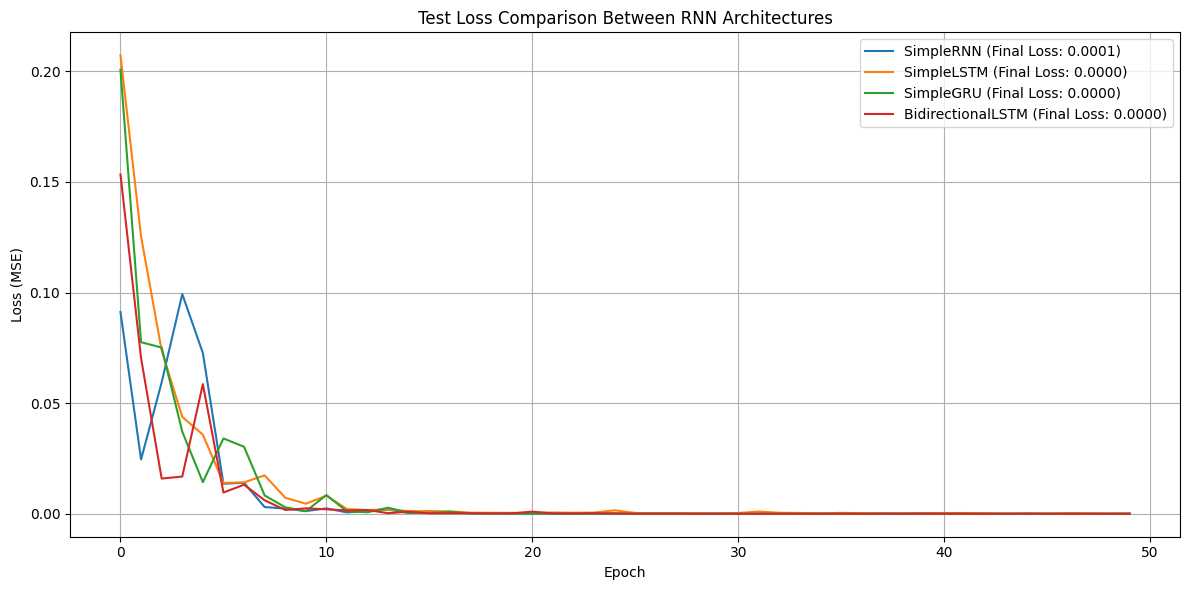

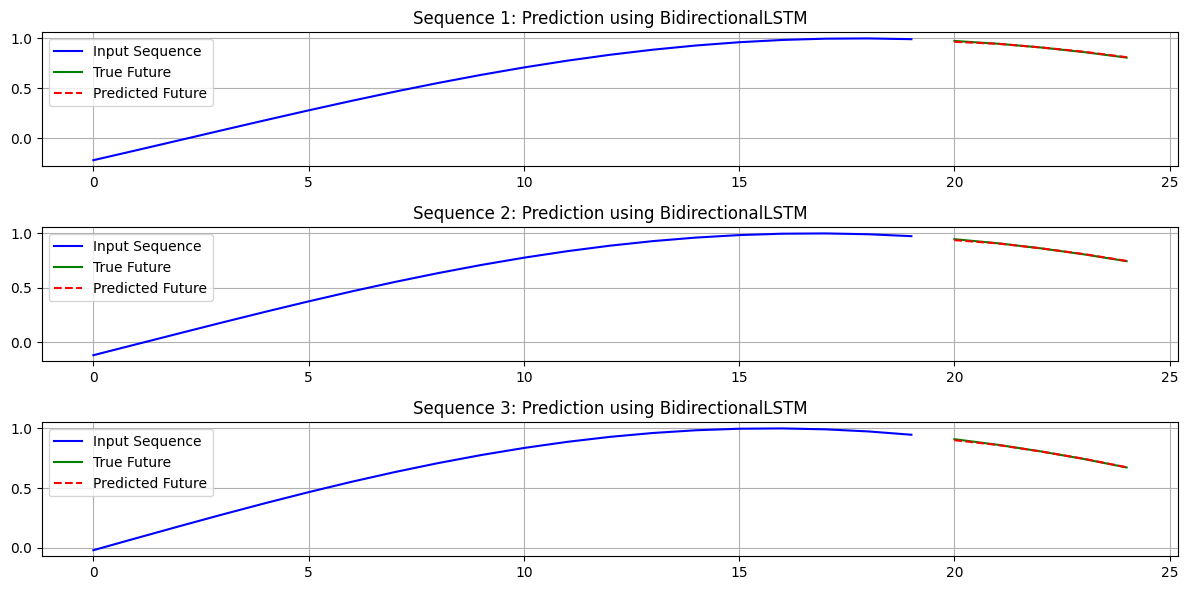

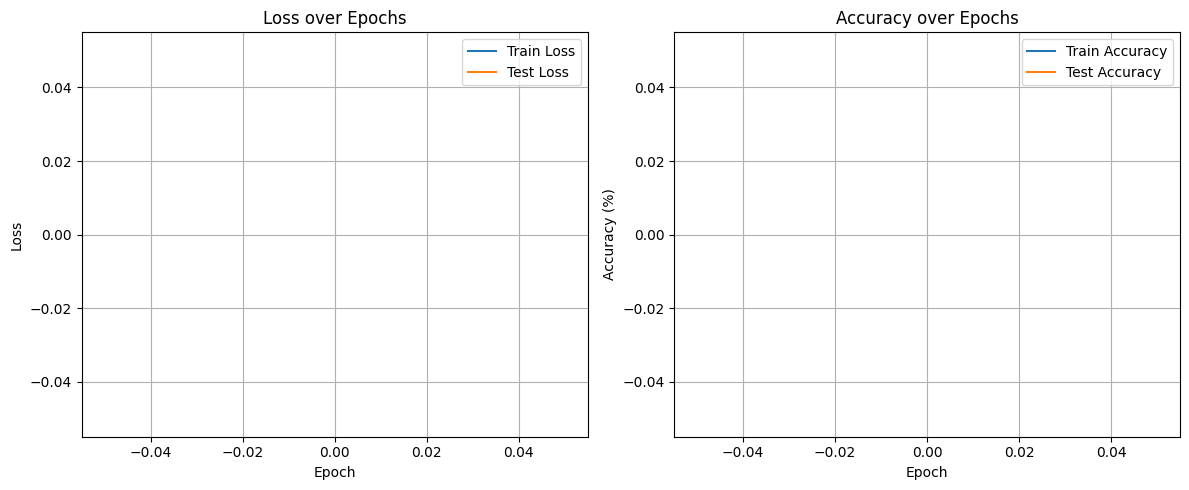

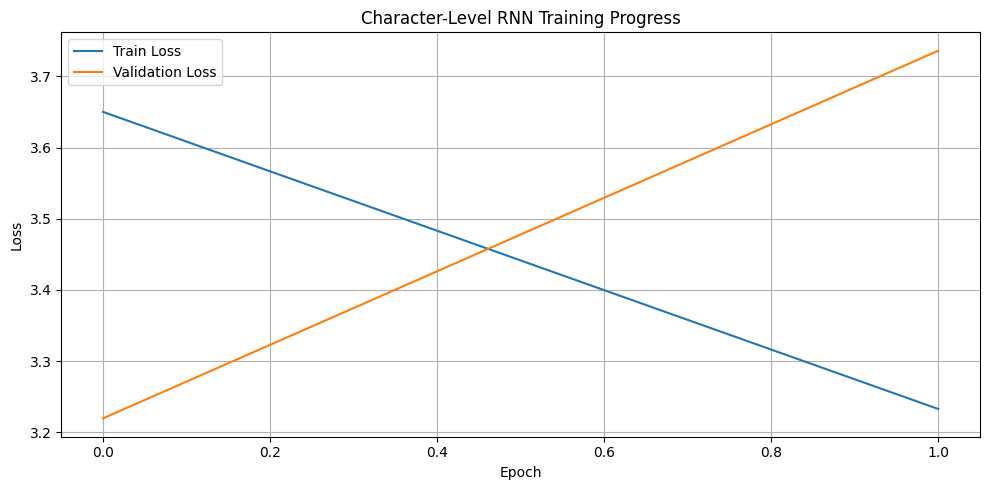

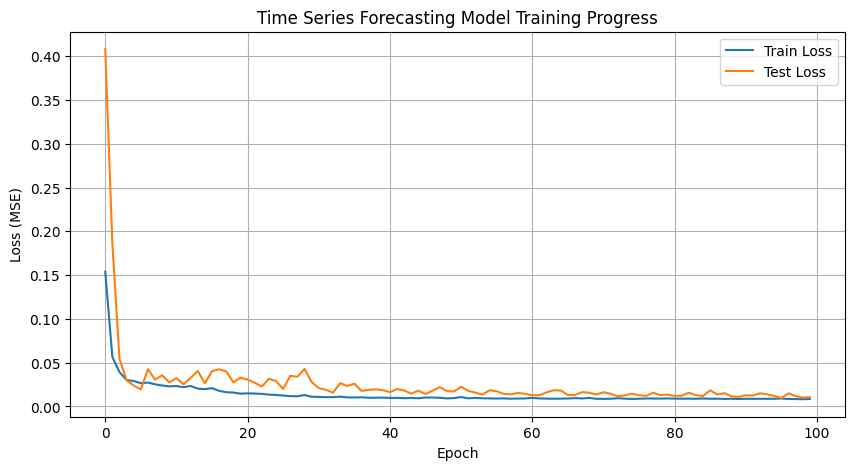

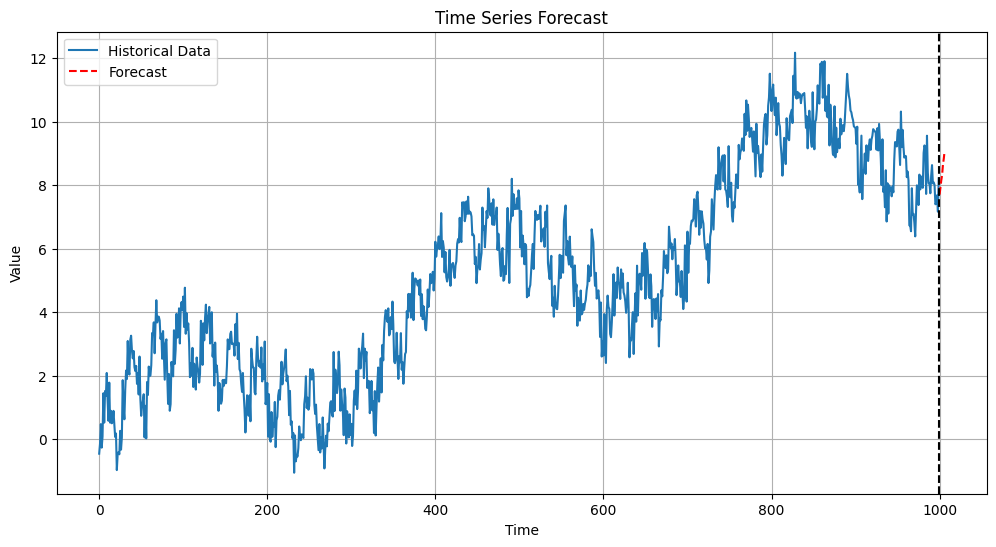

In [40]:
main()